# 📚 Práctica 9: Análisis de Texto (NLP) y Nube de Palabras

**Materia:** Minería de Datos (FCFM)  
**Tópico:** Procesamiento de Lenguaje Natural (NLP) básico.

**Contexto:** 
Nuestro dataset contiene telemetría del sistema operativo Linux (logs de `journalctl`). Hasta ahora, las prácticas se centraron en análisis numéricos, agrupamientos y series de tiempo. Sin embargo, la columna de **Mensajes** encierra comportamientos del ecosistema informático redactados en lenguaje humano/máquina.

**Objetivo Misión:** 
- Unificar la columna de mensajes de los logs en un solo corpus de texto.
- Ejecutar limpieza de ruido insertando *"Stopwords"* genéricos del idioma y del sistema Linux (ej. *systemd, localhost*).
- Instanciar y generar una **Nube de Palabras (WordCloud)** para visualizar los eventos, rutas o alertas más frecuentes.
- Interpretar el estado del sistema con Storytelling.

In [ ]:
# Importamos las herramientas necesarias
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

# 1. Cargamos el dataset limpio de tu primera práctica
df = pd.read_csv('../Practica_1/csv/dataset_linux_journalctl_limpio.csv')

# 2. Seleccionamos la columna de texto.
# Llenamos los posibles valores vacíos (NaN) con un string vacío
text_data = df['MensajeLog'].fillna('').astype(str)

# 3. Unimos todos los mensajes en un solo string gigante ("corpus")
corpus = " ".join(text_data)

# 4. Definimos nuestros Stopwords (palabras que no aportan significado)
# Utilizamos las que vienen por defecto en la librería y añadimos las típicas del ruido de Linux
mis_stopwords = set(STOPWORDS)
palabras_basura_linux = [
    'systemd', 'localhost', 'kernel', 'root', 'session', 'user', 
    'slice', 'started', 'run', 'starting', 'an', 'and', 'the', 'is', 'to', 'for'
]
mis_stopwords.update(palabras_basura_linux)

print(f"¡Corpus creado con éxito! Longitud total: {len(corpus)} caracteres.")

¡Corpus creado con éxito! Longitud total: 732943 caracteres.


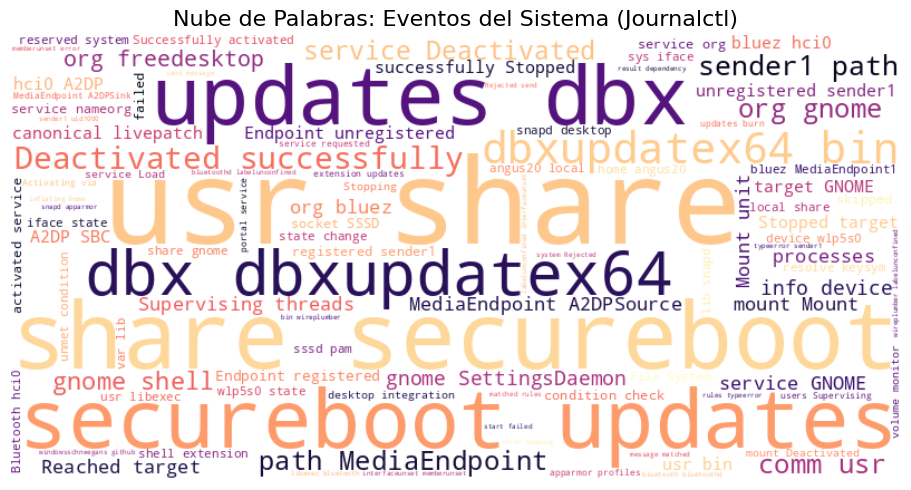

In [3]:
# 1. Instanciamos la clase WordCloud con nuestra configuración
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords=mis_stopwords,
    colormap='magma', # Un mapa de colores que se ve muy bien
    max_words=100
).generate(corpus)

# 2. Creamos la figura con un tamaño profesional (10x5)
plt.figure(figsize=(10, 5))

# 3. Mostramos la imagen generada
plt.imshow(wordcloud, interpolation='bilinear')

# 4. Quitamos los ejes para que se vea como una imagen limpia
plt.axis('off')
plt.title('Nube de Palabras: Eventos del Sistema (Journalctl)', fontsize=16)
plt.tight_layout()
plt.show()

### 📝 Conclusión del Análisis de Texto (Storytelling)

Al observar las palabras más gigantes en nuestra gráfica, podemos interpretar el "estado de ánimo" y la salud general de nuestro sistema:

1. **`updates`**: Nos indica que un volumen muy importante de nuestros registros se debe a operaciones del gestor de paquetes o chequeos del sistema buscando actualizaciones (probablemente servicios como `apt`, `dpkg` o `unattended-upgrades`). Esto significa que tu sistema está activamente manteniéndose al día.
2. **`secureboot`**: Refleja que hay múltiples registros relacionados con el proceso de arranque seguro de tu computadora. Linux está constantemente validando firmas digitales de los módulos del kernel al arrancar para prevenir software malicioso desde el inicio.
3. **`usr` y `share`**: Estas palabras corresponden a rutas estándar de Linux (como `/usr/share/...`), lo que indica que una gran cantidad de logs están reportando el acceso a archivos de configuración de lectura, recursos compartidos o librerías por parte de las aplicaciones instaladas.

**Insight Clave:** *Gracias a que limpiamos las palabras genéricas y repetitivas, la Nube de Palabras logra revelar a los verdaderos protagonistas de nuestra telemetría. Al no observar palabras como "error", "failed" o "critical" en gran tamaño, podemos concluir a simple vista que la salud general de tu entorno es estable y se trata de operaciones de rutina (rutas, actualizaciones y seguridad de encendido).*

**Autor**: Diego Leonardo Alejo Cantú

**Matrícula**: 2013810

**Materia**: Minería de Datos